In [2]:
%run Packages_and_Functions.ipynb
# %run Graph_Generators.ipynb
# %run Metric_Repair_Algorithms.ipynb
import scipy.special
from random import randrange


In [5]:
def avg_hyperbolicity(G,by_weight=False,both=False,reps=50):
    """
    Compute the average hyperbolicity of a graph G by sampling random 4-tuples of vertices.
    
    Parameters:
    G : Graph
        The input graph for which to compute the average hyperbolicity.
    reps : int, optional
        The number of random 4-tuples to sample (default is 50).
    
    Returns:
    float
        The average hyperbolicity of the graph.
    """
    n = G.num_verts()
    if n < 4:
        raise ValueError("Graph must have at least 4 vertices to compute hyperbolicity.")
    
    total_hyperbolicity = 0
    if not both:
        for _ in range(reps):
            # Sample 4 distinct vertices
            vertices = random.sample(G.vertices(), 4)
            a, b, c, d = vertices
            if not by_weight:    
                # Compute pairwise distances
                d_ab = G.distance(a, b)
                d_ac = G.distance(a, c)
                d_ad = G.distance(a, d)
                d_bc = G.distance(b, c)
                d_bd = G.distance(b, d)
                d_cd = G.distance(c, d)
            else:
                d_ab = G.distance(a, b,by_weight=1)
                d_ac = G.distance(a, c,by_weight=1)
                d_ad = G.distance(a, d,by_weight=1)
                d_bc = G.distance(b, c,by_weight=1)
                d_bd = G.distance(b, d,by_weight=1)
                d_cd = G.distance(c, d,by_weight=1)
            # Compute the three sums
            sum1 = d_ab + d_cd
            sum2 = d_ac + d_bd
            sum3 = d_ad + d_bc
            
            # Find the two largest sums and compute their difference
            sums = [sum1, sum2, sum3]
            sums.sort()

            while abs(sums[2]) == np.inf or abs(sums[1]) == np.inf: ## make sure distances are not infinite
                vertices = random.sample(G.vertices(), 4)
                a, b, c, d = vertices
                if not by_weight:    
                # Compute pairwise distances
                    d_ab = G.distance(a, b)
                    d_ac = G.distance(a, c)
                    d_ad = G.distance(a, d)
                    d_bc = G.distance(b, c)
                    d_bd = G.distance(b, d)
                    d_cd = G.distance(c, d)
                else:
                    d_ab = G.distance(a, b,by_weight=1)
                    d_ac = G.distance(a, c,by_weight=1)
                    d_ad = G.distance(a, d,by_weight=1)
                    d_bc = G.distance(b, c,by_weight=1)
                    d_bd = G.distance(b, d,by_weight=1)
                    d_cd = G.distance(c, d,by_weight=1)
                sum1 = d_ab + d_cd
                sum2 = d_ac + d_bd
                sum3 = d_ad + d_bc
                sums = [sum1, sum2, sum3]
                sums.sort()
            delta = (sums[2] - sums[1]) / 2
            
            total_hyperbolicity += delta
        
        avg_hyperbolicity = total_hyperbolicity / reps
        return avg_hyperbolicity
    else:
        total_hyperbolicity_unweighted = 0
        total_hyperbolicity_weighted = 0
        for _ in range(reps):
            # Sample 4 distinct vertices
            vertices = random.sample(G.vertices(), 4)
            a, b, c, d = vertices
            # Compute pairwise distances
            d_ab = G.distance(a, b)
            d_ac = G.distance(a, c)
            d_ad = G.distance(a, d)
            d_bc = G.distance(b, c)
            d_bd = G.distance(b, d)
            d_cd = G.distance(c, d)

            d_ab_w = G.distance(a, b,by_weight=1)
            d_ac_w = G.distance(a, c,by_weight=1)
            d_ad_w = G.distance(a, d,by_weight=1)
            d_bc_w = G.distance(b, c,by_weight=1)
            d_bd_w = G.distance(b, d,by_weight=1)
            d_cd_w = G.distance(c, d,by_weight=1)
            # Compute the three sums
            sum1 = d_ab + d_cd
            sum2 = d_ac + d_bd
            sum3 = d_ad + d_bc
            sum1_w = d_ab_w + d_cd_w
            sum2_w = d_ac_w + d_bd_w
            sum3_w = d_ad_w + d_bc_w
            # Find the two largest sums and compute their difference
            sums = [sum1, sum2, sum3]
            sums_w = [sum1_w, sum2_w, sum3_w]
            sums.sort()
            sums_w.sort()
            while abs(sums[2]) == np.inf or abs(sums[1]) == np.inf: ## make sure distances are not infinite
                print("infinite distance found, resampling")
                vertices = random.sample(G.vertices(), 4)
                a, b, c, d = vertices
                # Compute pairwise distances
                d_ab = G.distance(a, b)
                d_ac = G.distance(a, c)
                d_ad = G.distance(a, d)
                d_bc = G.distance(b, c)
                d_bd = G.distance(b, d)
                d_cd = G.distance(c, d)

                d_ab_w = G.distance(a, b,by_weight=1)
                d_ac_w = G.distance(a, c,by_weight=1)
                d_ad_w = G.distance(a, d,by_weight=1)
                d_bc_w = G.distance(b, c,by_weight=1)
                d_bd_w = G.distance(b, d,by_weight=1)
                d_cd_w = G.distance(c, d,by_weight=1)
                sum1 = d_ab + d_cd
                sum2 = d_ac + d_bd
                sum3 = d_ad + d_bc
                sum1_w = d_ab_w + d_cd_w
                sum2_w = d_ac_w + d_bd_w
                sum3_w = d_ad_w + d_bc_w
                sums = [sum1, sum2, sum3]
                sums_w = [sum1_w, sum2_w, sum3_w]
                sums.sort()
                sums_w.sort()
            delta = (sums[2] - sums[1]) / 2
            delta_w = (sums_w[2] - sums_w[1]) / 2
            total_hyperbolicity_unweighted += delta
            total_hyperbolicity_weighted += delta_w
        avg_hyperbolicity_unweighted = total_hyperbolicity_unweighted / reps
        avg_hyperbolicity_weighted = total_hyperbolicity_weighted / reps
        return (avg_hyperbolicity_unweighted,avg_hyperbolicity_weighted)
def shortest_path_histogram(G,by_weight=False):
    """
    Compute the histogram of shortest path lengths in a graph G.
    
    Parameters:
    G : Graph
        The input graph for which to compute the shortest path length histogram.
    by_weight : bool, optional
        If True, compute shortest paths using edge weights (default is False).
    
    Returns:
    dict
        A dictionary where keys are path lengths and values are their frequencies.
    """
    path_length_counts = {}
    vertices = G.vertices()
    n = len(vertices)
    
    for i in range(n):
        for j in range(i + 1, n):
            if not by_weight:
                length = G.distance(vertices[i], vertices[j])
            else:
                length = G.distance(vertices[i], vertices[j], by_weight=1)
            
            if length not in path_length_counts:
                path_length_counts[length] = 0
            path_length_counts[length] += 1
    
    return path_length_counts

def TV_distance(hist1, hist2):
    """
    Compute the total variation distance between two histograms.
    
    Parameters:
    hist1 : dict
        The first histogram as a dictionary of counts.
    hist2 : dict
        The second histogram as a dictionary of counts.
    
    Returns:
    float
        The total variation distance between the two histograms.
    """
    all_keys = set(hist1.keys()).union(set(hist2.keys()))
    total1 = sum(hist1.values())
    total2 = sum(hist2.values())
    
    tv_distance = 0
    for key in all_keys:
        p1 = hist1.get(key, 0) / total1 if total1 > 0 else 0
        p2 = hist2.get(key, 0) / total2 if total2 > 0 else 0
        tv_distance += abs(p1 - p2)
    
    return tv_distance / 2




In [ ]:
# ## Set Up AVG hyperbolicity experiment
# # alpha=4/5
# Alpha=np.linspace(.1,.9,5)
# p = lambda x: np.power(n,-x)
# N = range(60,80)
# reps = 20
# results = np.zeros((len(N),reps,len(Alpha)))
# for i in range(len(N)):
#     for k,alpha in enumerate(Alpha):
#         for j in range(reps):
#             G = random_geometric_weighted_graph(N[i],p(alpha))
#             results[i,j,k] = avg_hyperbolicity(G)
#             print("N = ",N[i]," rep = ",j,"alpha = ",alpha, "avg hyperbolicity = ",results[i,j,k])



In [334]:
n=100
# Alpha=np.concatenate((np.linspace(.1,.6,10),np.linspace(.7,.9,10)))
Alpha=np.linspace(.1,.9,50)
# Alpha = np.concatenate((np.linspace(.1,.6,20),np.linspace(.7,.9,10)))
p = lambda x: np.power(n,-x)
reps = 30
results_alpha = np.zeros((len(Alpha),reps))
results_alpha_by_weight = np.zeros((len(Alpha),reps))
results_diameter = np.zeros((len(Alpha),reps))
results_diameter_by_weight = np.zeros((len(Alpha),reps))
results_TV_distance_distribution=np.zeros((len(Alpha),reps))
for i,alpha in enumerate(Alpha):
    for j in range(reps):
        G = random_geometric_weighted_graph(n,p(alpha))
        results_alpha[i,j],results_alpha_by_weight[i,j] = avg_hyperbolicity(G,both=True,reps=30)
        results_alpha_by_weight[i,j] = avg_hyperbolicity(G,by_weight=1)
        D = max([G.subgraph(V).diameter() for V in G.connected_components()])
        results_diameter[i,j] = D
        D_by_weight = max([G.subgraph(V).diameter(by_weight=1,algorithm='Dijkstra_NetworkX') for V in G.connected_components()])
        results_diameter_by_weight[i,j] = D_by_weight
        L1 = shortest_path_histogram(G,by_weight=True)
        L2 = shortest_path_histogram(G,by_weight=False)
        results_TV_distance_distribution[i,j] = TV_distance(L1,L2)
        print("alpha = ",alpha,"rep = ",j, "avg hyperbolicity = ",results_alpha[i,j]," by weight = ", results_alpha_by_weight[i,j])


/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/1043052736.py:84: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))
/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/1043052736.py:23: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))
/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/1043052736.py:162: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = G.vertices()


alpha =  0.1 rep =  0 avg hyperbolicity =  0.31666666666666665  by weight =  0.0
alpha =  0.1 rep =  1 avg hyperbolicity =  0.36666666666666664  by weight =  0.0
alpha =  0.1 rep =  2 avg hyperbolicity =  0.35  by weight =  0.0
alpha =  0.1 rep =  3 avg hyperbolicity =  0.2833333333333333  by weight =  0.0
alpha =  0.1 rep =  4 avg hyperbolicity =  0.2833333333333333  by weight =  0.0
alpha =  0.1 rep =  5 avg hyperbolicity =  0.3333333333333333  by weight =  0.0
alpha =  0.1 rep =  6 avg hyperbolicity =  0.2833333333333333  by weight =  0.0
alpha =  0.1 rep =  7 avg hyperbolicity =  0.25  by weight =  0.0
alpha =  0.1 rep =  8 avg hyperbolicity =  0.26666666666666666  by weight =  0.0
alpha =  0.1 rep =  9 avg hyperbolicity =  0.35  by weight =  0.0
alpha =  0.1 rep =  10 avg hyperbolicity =  0.31666666666666665  by weight =  0.5
alpha =  0.1 rep =  11 avg hyperbolicity =  0.3333333333333333  by weight =  0.5
alpha =  0.1 rep =  12 avg hyperbolicity =  0.36666666666666664  by weight =

/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/1043052736.py:114: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


alpha =  0.7040816326530612 rep =  12 avg hyperbolicity =  0.26666666666666666  by weight =  0.5
alpha =  0.7040816326530612 rep =  13 avg hyperbolicity =  0.4166666666666667  by weight =  0.5
alpha =  0.7040816326530612 rep =  14 avg hyperbolicity =  0.4  by weight =  0.0
alpha =  0.7040816326530612 rep =  15 avg hyperbolicity =  0.3333333333333333  by weight =  0.0
alpha =  0.7040816326530612 rep =  16 avg hyperbolicity =  0.35  by weight =  0.0
alpha =  0.7040816326530612 rep =  17 avg hyperbolicity =  0.45  by weight =  1.0
alpha =  0.7040816326530612 rep =  18 avg hyperbolicity =  0.35  by weight =  0.5
alpha =  0.7040816326530612 rep =  19 avg hyperbolicity =  0.3  by weight =  0.0
alpha =  0.7040816326530612 rep =  20 avg hyperbolicity =  0.43333333333333335  by weight =  0.0
alpha =  0.7040816326530612 rep =  21 avg hyperbolicity =  0.43333333333333335  by weight =  0.5
alpha =  0.7040816326530612 rep =  22 avg hyperbolicity =  0.4166666666666667  by weight =  0.0
alpha =  0.70

/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/1043052736.py:51: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


alpha =  0.7040816326530612 rep =  27 avg hyperbolicity =  0.31666666666666665  by weight =  0.0
alpha =  0.7040816326530612 rep =  28 avg hyperbolicity =  0.3  by weight =  0.5
alpha =  0.7040816326530612 rep =  29 avg hyperbolicity =  0.36666666666666664  by weight =  1.5
alpha =  0.7204081632653062 rep =  0 avg hyperbolicity =  0.4666666666666667  by weight =  1.0
alpha =  0.7204081632653062 rep =  1 avg hyperbolicity =  0.55  by weight =  0.5
alpha =  0.7204081632653062 rep =  2 avg hyperbolicity =  0.48333333333333334  by weight =  0.5
alpha =  0.7204081632653062 rep =  3 avg hyperbolicity =  0.4666666666666667  by weight =  0.0
alpha =  0.7204081632653062 rep =  4 avg hyperbolicity =  0.43333333333333335  by weight =  0.5
alpha =  0.7204081632653062 rep =  5 avg hyperbolicity =  0.21666666666666667  by weight =  0.5
alpha =  0.7204081632653062 rep =  6 avg hyperbolicity =  0.55  by weight =  0.0
alpha =  0.7204081632653062 rep =  7 avg hyperbolicity =  0.43333333333333335  by wei

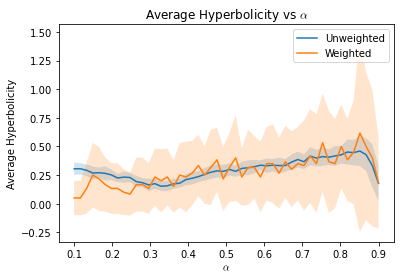

In [ ]:
## Plot AVG hyperbolicity experiment
plt.figure()
plt.xlabel("$\\alpha$")
plt.ylabel('Average Hyperbolicity')
plt.title('Average Hyperbolicity vs $\\alpha$')
# plt.errorbar(N,np.mean(results, axis=1),yerr=np.std(results,axis=1),fmt='o',capsize=5)
plt.plot(Alpha,np.mean(results_alpha,axis=1),label="Unweighted")
plt.fill_between(Alpha,np.mean(results_alpha,axis=1)-np.std(results_alpha,axis=1),np.mean(results_alpha,axis=1)+np.std(results_alpha,axis=1),alpha=0.2)
plt.plot(Alpha,np.mean(results_alpha_by_weight,axis=1),label="Weighted")
plt.fill_between(Alpha,np.mean(results_alpha_by_weight,axis=1)-np.std(results_alpha_by_weight,axis=1),np.mean(results_alpha_by_weight,axis=1)+np.std(results_alpha_by_weight,axis=1),alpha=0.2)
plt.legend()
plt.show()


In [397]:
n=150
# Alpha=np.concatenate((np.linspace(.1,.6,10),np.linspace(.7,.9,10)))
Alpha=np.linspace(.1,.9,20)
# Alpha = np.concatenate((np.linspace(.1,.6,20),np.linspace(.7,.9,10)))
p = lambda x: np.power(n,-x)
reps = 30
eq_results_alpha = np.zeros((len(Alpha),reps))
eq_results_alpha_by_weight = np.zeros((len(Alpha),reps))
same_pts_results_alpha = np.zeros((len(Alpha),reps))
same_pts_results_alpha_by_weight = np.zeros((len(Alpha),reps))
# 2results_diameter = np.zeros((len(Alpha),reps))
# 2results_diameter_by_weight = np.zeros((len(Alpha),reps))
# 2results_TV_distance_distribution=np.zeros((len(Alpha),reps))
for i,alpha in enumerate(Alpha):
    for j in range(reps):
        G = random_geometric_weighted_graph(n,p(alpha))
        # eq_results_alpha[i,j],eq_results_alpha_by_weight[i,j] = avg_hyperbolicity(G,reps=30),avg_hyperbolicity(G,by_weight=1,reps=30)
        same_pts_results_alpha[i,j],same_pts_results_alpha_by_weight[i,j] = avg_hyperbolicity(G,both=True,reps=30)
        # results_alpha_by_weight[i,j] = avg_hyperbolicity(G,by_weight=1)
        # D = max([G.subgraph(V).diameter() for V in G.connected_components()])
        # results_diameter[i,j] = D
        # D_by_weight = max([G.subgraph(V).diameter(by_weight=1,algorithm='Dijkstra_NetworkX') for V in G.connected_components()])
        # results_diameter_by_weight[i,j] = D_by_weight
        # L1 = shortest_path_histogram(G,by_weight=True)
        # L2 = shortest_path_histogram(G,by_weight=False)
        # results_TV_distance_distribution[i,j] = TV_distance(L1,L2)
        print("alpha = ",alpha,"rep = ",j, "avg hyperbolicity = ",eq_results_alpha[i,j]," by weight = ", eq_results_alpha_by_weight[i,j])


/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/665818269.py:83: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


alpha =  0.1 rep =  0 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  1 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  2 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  3 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  4 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  5 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  6 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  7 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  8 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  9 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  10 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  11 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  12 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  13 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  14 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.1 rep =  

/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/665818269.py:113: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


infinite distance found, resampling
alpha =  0.731578947368421 rep =  6 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  7 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  8 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  9 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  10 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  11 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  12 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  13 avg hyperbolicity =  0.0  by weight =  0.0
infinite distance found, resampling
infinite distance found, resampling
infinite distance found, resampling
infinite distance found, resampling
alpha =  0.731578947368421 rep =  14 avg hyperbolicity =  0.0  by weight =  0.0
alpha =  0.731578947368421 rep =  15 avg hyperbolicity =  0.0  by weight =  0.0
infinite distance found,

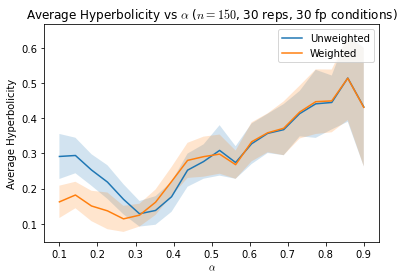

In [399]:
## Plot AVG hyperbolicity experiment
plt.figure()
plt.xlabel("$\\alpha$")
plt.ylabel('Average Hyperbolicity')
plt.title('Average Hyperbolicity vs $\\alpha$ ($n=150$, 30 reps, 30 fp conditions)')
# plt.errorbar(N,np.mean(results, axis=1),yerr=np.std(results,axis=1),fmt='o',capsize=5)
# plt.plot(Alpha,np.mean(eq_results_alpha,axis=1),label="Unweighted")
# plt.fill_between(Alpha,np.mean(eq_results_alpha,axis=1)-np.std(eq_results_alpha,axis=1),np.mean(eq_results_alpha,axis=1)+np.std(eq_results_alpha,axis=1),alpha=0.2)
# plt.plot(Alpha,np.mean(eq_results_alpha_by_weight,axis=1),label="Weighted")
# plt.fill_between(Alpha,np.mean(eq_results_alpha_by_weight,axis=1)-np.std(eq_results_alpha_by_weight,axis=1),np.mean(eq_results_alpha_by_weight,axis=1)+np.std(eq_results_alpha_by_weight,axis=1),alpha=0.2)

plt.plot(Alpha,np.mean(same_pts_results_alpha,axis=1),label="Unweighted")
plt.fill_between(Alpha,np.mean(same_pts_results_alpha,axis=1)-np.std(same_pts_results_alpha,axis=1),np.mean(same_pts_results_alpha,axis=1)+np.std(same_pts_results_alpha,axis=1),alpha=0.2)
plt.plot(Alpha,np.mean(same_pts_results_alpha_by_weight,axis=1),label="Weighted")
plt.fill_between(Alpha,np.mean(same_pts_results_alpha_by_weight,axis=1)-np.std(same_pts_results_alpha_by_weight,axis=1),np.mean(same_pts_results_alpha_by_weight,axis=1)+np.std(same_pts_results_alpha_by_weight,axis=1),alpha=0.2)

plt.legend()
plt.savefig("AVG_hyperbolicity_vs_alpha_n150_30fp_30reps.pdf")

# plt.show()

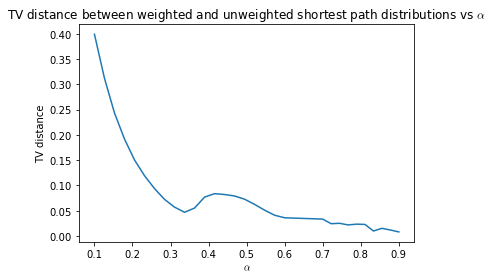

In [ ]:
plt.plot(Alpha,np.mean(results_TV_distance_distribution,axis=1),label="TV distance distribution")
plt.title('TV distance between weighted and unweighted shortest path distributions vs $\\alpha$')
plt.xlabel("$\\alpha$")
plt.ylabel('TV distance')
plt.show()

In [ ]:
## Same experiment, but for p = \lambda/n. Results are not interesting.
# n=150
# Lambda=np.linspace(5,25,30)
# p = lambda x: x/n
# reps = 30
# results_Lambda = np.zeros((len(Lambda),reps))
# results_Lambda_by_weight = np.zeros((len(Lambda),reps))
# results_diameter = np.zeros((len(Lambda),reps))
# results_diameter_by_weight = np.zeros((len(Lambda),reps))
# for i,lambd in enumerate(Lambda):
#     for j in range(reps):
#         G = random_geometric_weighted_graph(n,p(lamb))
#         results_Lambda[i,j] = avg_hyperbolicity(G)
#         results_Lambda_by_weight[i,j] = avg_hyperbolicity(G,by_weight=1)
#         D = max([G.subgraph(V).diameter() for V in G.connected_components()])
#         results_diameter[i,j] = D
#         D_by_weight = max([G.subgraph(V).diameter(by_weight=1,algorithm='Dijkstra_NetworkX') for V in G.connected_components()])
#         results_diameter_by_weight[i,j] = D_by_weight
#         print("lambda = ",lambd,"rep = ",j, "avg hyperbolicity = ",results_alpha[i,j])


/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/4058888719.py:22: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


lambda =  5.0 rep =  0 avg hyperbolicity =  0.24
lambda =  5.0 rep =  1 avg hyperbolicity =  0.25
lambda =  5.0 rep =  2 avg hyperbolicity =  0.33
lambda =  5.0 rep =  3 avg hyperbolicity =  0.27
lambda =  5.0 rep =  4 avg hyperbolicity =  0.33
lambda =  5.0 rep =  5 avg hyperbolicity =  0.26
lambda =  5.0 rep =  6 avg hyperbolicity =  0.28
lambda =  5.0 rep =  7 avg hyperbolicity =  0.28


KeyboardInterrupt: 

In [417]:
# average diameter as n goes to infty, fixed alpha. see if converges.

n_values = np.linspace(100, 300, 10, dtype=int)
reps = 30
alphas = np.linspace(0.2,0.5,3)
p = lambda x: np.power(n,-x)
a_results=np.zeros((len(alphas),len(n_values),reps))
a_results_by_weight=np.zeros((len(alphas),len(n_values),reps))
for k,alpha in enumerate(alphas):
    for i,n in enumerate(n_values):
        for j in range(reps):
            G = random_geometric_weighted_graph(n,p(alpha))
            a_results[k,i,j] = max([G.subgraph(V).diameter() for V in G.connected_components()])
            a_results_by_weight[k,i,j] = max([G.subgraph(V).diameter(by_weight=1,algorithm='Dijkstra_NetworkX') for V in G.connected_components()])
            print("n = ",n," rep = ",j," alpha = ",alpha," diameter = ",a_results[k,i,j]," by weight = ",a_results_by_weight[k,i,j])
        
    # average diameter as n goes to infty  

n =  100  rep =  0  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  1  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  2  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  3  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  4  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  5  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  6  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  7  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  8  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  9  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  10  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  11  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  12  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  13  alpha =  0.2  diameter =  2.0  by weight =  3.0
n =  100  rep =  14  alpha =  0.2  diameter 

KeyboardInterrupt: 

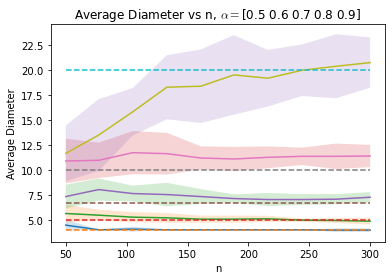

In [415]:
plt.figure()
plt.xlabel("n")
plt.ylabel('Average Diameter')
plt.title('Average Diameter vs n, $\\alpha=$'+str(alphas))
for k,alpha in enumerate(alphas):
    # plt.errorbar(N,np.mean(results, axis=1),yerr=np.std(results,axis=1),fmt='o',capsize=5)
    # plt.plot(n_values,np.mean(a_results[k,:,:],axis=1),label="Unweighted")
    # plt.fill_between(n_values,np.mean(a_results[k,:,:],axis=1)-np.std(a_results[k,:,:],axis=1),np.mean(a_results[k,:,:],axis=1)+np.std(a_results[k,:,:],axis=1),alpha=0.2)
    # plt.plot(n_values,[2/(1-alpha)]*len(n_values),label="$2/(1-\\alpha)$",linestyle='dashed')
    plt.plot(n_values,np.mean(a_results_by_weight[k,:,:],axis=1),label="Weighted")
    plt.fill_between(n_values,np.mean(a_results_by_weight[k,:,:],axis=1)-np.std(a_results_by_weight[k,:,:],axis=1),np.mean(a_results_by_weight[k,:,:],axis=1)+np.std(a_results_by_weight[k,:,:],axis=1),alpha=0.2)
    plt.plot(n_values,[2/(1-alpha)]*len(n_values),label="$2/\\alpha)$",linestyle='dashed')
# plt.legend()
plt.show()


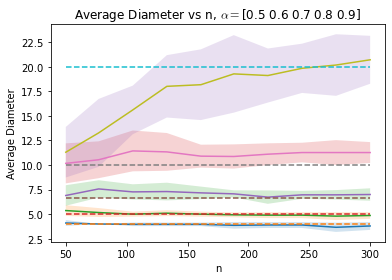

In [414]:
plt.figure()
plt.xlabel("n")
plt.ylabel('Average Diameter')
plt.title('Average Diameter vs n, $\\alpha=$'+str(alphas))
for k,alpha in enumerate(alphas):
    # plt.errorbar(N,np.mean(results, axis=1),yerr=np.std(results,axis=1),fmt='o',capsize=5)
    plt.plot(n_values,np.mean(a_results[k,:,:],axis=1),label="Unweighted")
    plt.fill_between(n_values,np.mean(a_results[k,:,:],axis=1)-np.std(a_results[k,:,:],axis=1),np.mean(a_results[k,:,:],axis=1)+np.std(a_results[k,:,:],axis=1),alpha=0.2)
    plt.plot(n_values,[2/(1-alpha)]*len(n_values),label="$2/(1-\\alpha)$",linestyle='dashed')
    # plt.plot(n_values,np.mean(a_results_by_weight[k,:,:],axis=1),label="Weighted")
    # plt.fill_between(n_values,np.mean(a_results_by_weight[k,:,:],axis=1)-np.std(a_results_by_weight[k,:,:],axis=1),np.mean(a_results_by_weight[k,:,:],axis=1)+np.std(a_results_by_weight[k,:,:],axis=1),alpha=0.2)
    # plt.plot(n_values,[2/(1-alpha)]*len(n_values),label="$2/\\alpha)$",linestyle='dashed')
# plt.legend()
plt.show()


In [380]:
# Average hyperbolicity as n goes to infty, fixed alpha. see if converges.
n_values = np.linspace(50, 300, 10, dtype=int)
reps = 30
eq_results_n = np.zeros((len(n_values),reps))
eq_results_n_by_weight = np.zeros((len(n_values),reps))
for i,n in enumerate(n_values):
    for j in range(reps):
        G = random_geometric_weighted_graph(n,p(0.5))
        eq_results_n[i,j],eq_results_n_by_weight[i,j] = avg_hyperbolicity(G,both=True, reps=30)
#a      


/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_53355/665818269.py:83: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


KeyboardInterrupt: 

In [ ]:
plt.figure()
plt.xlabel("n")
plt.ylabel('Average Heperbolicity')
plt.title('Average hyperbolicity vs n')

plt.plot(n_values,np.mean(eq_results_n,axis=1),label="Unweighted")
plt.fill_between(n_values,np.mean(eq_results_n,axis=1)-np.std(eq_results_n,axis=1),np.mean(eq_results_n,axis=1)+np.std(eq_results_n,axis=1),alpha=0.2)
plt.plot(n_values,np.mean(eq_results_n_by_weight,axis=1),label="Weighted")
plt.fill_between(n_values,np.mean(eq_results_n_by_weight,axis=1)-np.std(eq_results_n_by_weight,axis=1),np.mean(eq_results_n_by_weight,axis=1)+np.std(eq_results_n_by_weight,axis=1),alpha=0.2)
plt.legend()
plt.show()

In [31]:
n = 3000
p = np.power(n,-0.1)
reps = 30
large_n_results = np.zeros(reps)
large_n_results_by_weight = np.zeros(reps)
for i in range(reps):
    G = random_geometric_weighted_graph(n,p)
    large_n_results[i], large_n_results_by_weight[i] = avg_hyperbolicity(G,both=True,reps=30)
    print("rep ",i," avg hyperbolicity = ",large_n_results[i]," by weight = ",large_n_results_by_weight[i])


KeyboardInterrupt: 

In [408]:
print((np.mean(large_n_results)-np.std(large_n_results), np.mean(large_n_results)+np.std(large_n_results)))
print((np.mean(large_n_results_by_weight)-np.std(large_n_results_by_weight), np.mean(large_n_results_by_weight)+np.std(large_n_results_by_weight)))

(0.2305787094476614, 0.323865734996783)
(0.11958036571235821, 0.21708630095430853)


In [56]:
N_values = np.linspace(1000, 3000, 10, dtype=int)
reps = 40
p = lambda x: np.power(n,-x)
Alpah=np.linspace(.1,.9,5)
avg_hyperbolicity_results = np.zeros((len(Alpah),len(N_values),reps))
for k,alpha in enumerate(Alpah):
    for i,n in enumerate(N_values):
        for j in range(reps):
            G = RandomGNP(n,p(alpha))
            avg_hyperbolicity_results[k,i,j] = avg_hyperbolicity(G)
            print("N = ",n," rep = ",j," alpha = ",alpha," avg hyperbolicity = ",avg_hyperbolicity_results[k,i,j])

/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_39471/665818269.py:23: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


N =  1000  rep =  0  alpha =  0.1  avg hyperbolicity =  0.29
N =  1000  rep =  1  alpha =  0.1  avg hyperbolicity =  0.32
N =  1000  rep =  2  alpha =  0.1  avg hyperbolicity =  0.29
N =  1000  rep =  3  alpha =  0.1  avg hyperbolicity =  0.27
N =  1000  rep =  4  alpha =  0.1  avg hyperbolicity =  0.29
N =  1000  rep =  5  alpha =  0.1  avg hyperbolicity =  0.25
N =  1000  rep =  6  alpha =  0.1  avg hyperbolicity =  0.26
N =  1000  rep =  7  alpha =  0.1  avg hyperbolicity =  0.3
N =  1000  rep =  8  alpha =  0.1  avg hyperbolicity =  0.2
N =  1000  rep =  9  alpha =  0.1  avg hyperbolicity =  0.32
N =  1000  rep =  10  alpha =  0.1  avg hyperbolicity =  0.34
N =  1000  rep =  11  alpha =  0.1  avg hyperbolicity =  0.27
N =  1000  rep =  12  alpha =  0.1  avg hyperbolicity =  0.33
N =  1000  rep =  13  alpha =  0.1  avg hyperbolicity =  0.25
N =  1000  rep =  14  alpha =  0.1  avg hyperbolicity =  0.34
N =  1000  rep =  15  alpha =  0.1  avg hyperbolicity =  0.25
N =  1000  rep =  16

/var/folders/xr/lyydmwyj1fsb9yhb3tspbn1h0000gn/T/ipykernel_39471/665818269.py:50: DeprecationWarning: parameter 'sort' will be set to False by default in the future
See http://trac.sagemath.org/22349 for details.
  vertices = random.sample(G.vertices(), Integer(4))


N =  1222  rep =  6  alpha =  0.7000000000000001  avg hyperbolicity =  0.32
N =  1222  rep =  7  alpha =  0.7000000000000001  avg hyperbolicity =  0.35
N =  1222  rep =  8  alpha =  0.7000000000000001  avg hyperbolicity =  0.31
N =  1222  rep =  9  alpha =  0.7000000000000001  avg hyperbolicity =  0.36
N =  1222  rep =  10  alpha =  0.7000000000000001  avg hyperbolicity =  0.32
N =  1222  rep =  11  alpha =  0.7000000000000001  avg hyperbolicity =  0.25
N =  1222  rep =  12  alpha =  0.7000000000000001  avg hyperbolicity =  0.33
N =  1222  rep =  13  alpha =  0.7000000000000001  avg hyperbolicity =  0.26
N =  1222  rep =  14  alpha =  0.7000000000000001  avg hyperbolicity =  0.36
N =  1222  rep =  15  alpha =  0.7000000000000001  avg hyperbolicity =  0.25
N =  1222  rep =  16  alpha =  0.7000000000000001  avg hyperbolicity =  0.3
N =  1222  rep =  17  alpha =  0.7000000000000001  avg hyperbolicity =  0.31
N =  1222  rep =  18  alpha =  0.7000000000000001  avg hyperbolicity =  0.29
N = 

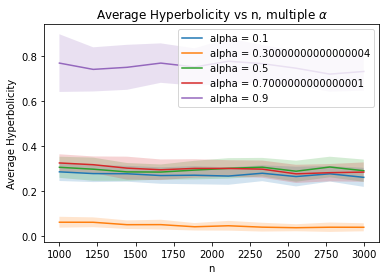

In [72]:
plt.figure()
plt.xlabel("n")
plt.ylabel('Average Hyperbolicity')
plt.title('Average Hyperbolicity vs n, multiple $\\alpha$')
# plt.errorbar(N,np.mean(results, axis=1),yerr=np.std(results,axis=1),fmt='o',capsize=5)
for k,alph in enumerate(Alpah):
    plt.plot(N_values,np.mean(avg_hyperbolicity_results[k,:,:],axis=1),label="alpha = "+str(alph))
    # plt.plot(N_values,[1/(1-alph)]*len(N_values),label="$1/(2\\alpha)$",linestyle='dashed')    
    plt.fill_between(N_values,np.mean(avg_hyperbolicity_results[k,:,:],axis=1)-np.std(avg_hyperbolicity_results[k,:,:],axis=1),np.mean(avg_hyperbolicity_results[k,:,:],axis=1)+np.std(avg_hyperbolicity_results[k,:,:],axis=1),alpha=0.2)
plt.legend()
# plt.plot(Probs,np.mean(pro
plt.savefig("AVG_hyperbolicity_vs_n_ER.pdf")

In [ ]:
ERgraph = (3000,0.05)